# AIS Solution – AI Internship

## Task 7: Data Analysis / AI-ML

### Topic: Outlier Detection and Data Preprocessing

### Objective

The objective of this task is to understand and implement different techniques for detecting outliers and analyzing data.

### Techniques Covered

- Box and Whisker Plot
- Quartile Calculation
- Tukey's Method / IQR
- Z-Score
- Standardization
- Scatter Plot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Iris dataset

iris = sns.load_dataset("iris")

# Display first 5 rows

print("First 5 rows of Iris dataset:")
print(iris.head())

First 5 rows of Iris dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [3]:
# Check dataset information

print("Dataset Shape:", iris.shape)

print("\nDataset Information:")
iris.info()

Dataset Shape: (150, 5)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


## 1. Outlier Detection Using Box and Whisker Plot

A box and whisker plot is used to visualize the distribution of numerical data and identify possible outliers.

The plot shows:
- Minimum value
- Q1 (First Quartile)
- Median (Q2)
- Q3 (Third Quartile)
- Maximum value
- Possible outliers

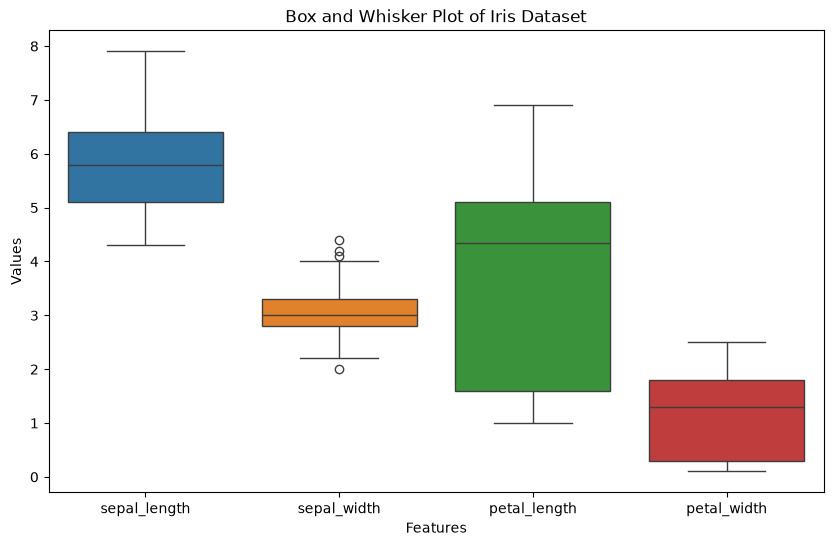

In [4]:
# Box and whisker plots for numerical columns

plt.figure(figsize=(10, 6))

sns.boxplot(data=iris.drop(columns="species"))

plt.title("Box and Whisker Plot of Iris Dataset")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

## 2. Quartile Calculation

Quartiles divide the data into four parts.

- Q1 = 25th percentile
- Q2 = 50th percentile (Median)
- Q3 = 75th percentile

Interquartile Range:

IQR = Q3 - Q1

In [5]:
# Calculate Q1, Q2 and Q3

numerical_columns = iris.select_dtypes(include=np.number).columns

for column in numerical_columns:
    Q1 = iris[column].quantile(0.25)
    Q2 = iris[column].quantile(0.50)
    Q3 = iris[column].quantile(0.75)

    print(f"\n{column}")
    print("Q1 =", Q1)
    print("Q2 (Median) =", Q2)
    print("Q3 =", Q3)


sepal_length
Q1 = 5.1
Q2 (Median) = 5.8
Q3 = 6.4

sepal_width
Q1 = 2.8
Q2 (Median) = 3.0
Q3 = 3.3

petal_length
Q1 = 1.6
Q2 (Median) = 4.35
Q3 = 5.1

petal_width
Q1 = 0.3
Q2 (Median) = 1.3
Q3 = 1.8


## 3. Tukey's Method for Outlier Detection

Tukey's method uses the Interquartile Range (IQR) to identify potential outliers.

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Values below the lower bound or above the upper bound are considered potential outliers.

In [6]:
# Detect outliers using Tukey's Method

for column in numerical_columns:
    Q1 = iris[column].quantile(0.25)
    Q3 = iris[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = iris[
        (iris[column] < lower_bound) |
        (iris[column] > upper_bound)
    ]

    print(f"\n{column}")
    print("Q1 =", Q1)
    print("Q3 =", Q3)
    print("IQR =", IQR)
    print("Lower Bound =", lower_bound)
    print("Upper Bound =", upper_bound)
    print("Number of Outliers =", len(outliers))


sepal_length
Q1 = 5.1
Q3 = 6.4
IQR = 1.3000000000000007
Lower Bound = 3.1499999999999986
Upper Bound = 8.350000000000001
Number of Outliers = 0

sepal_width
Q1 = 2.8
Q3 = 3.3
IQR = 0.5
Lower Bound = 2.05
Upper Bound = 4.05
Number of Outliers = 4

petal_length
Q1 = 1.6
Q3 = 5.1
IQR = 3.4999999999999996
Lower Bound = -3.649999999999999
Upper Bound = 10.349999999999998
Number of Outliers = 0

petal_width
Q1 = 0.3
Q3 = 1.8
IQR = 1.5
Lower Bound = -1.95
Upper Bound = 4.05
Number of Outliers = 0


## 4. Z-Score

Z-Score is used to determine how far a data value is from the mean.

### Formula

Z = (X - μ) / σ

Where:

- X = Data value
- μ = Mean of the data
- σ = Standard deviation

A Z-score tells us how many standard deviations a value is away from the mean.

Generally:
- Z-score near 0 → value is close to the mean
- Large positive Z-score → value is above the mean
- Large negative Z-score → value is below the mean
- Z-score greater than +3 or less than -3 can be considered a potential outlier.

In [7]:
# Calculate Z-Score for each numerical feature

for column in numerical_columns:
    mean = iris[column].mean()
    std = iris[column].std()

    iris[column + "_zscore"] = (iris[column] - mean) / std

print("Z-Score calculation completed!")
print(iris.head())

Z-Score calculation completed!
   sepal_length  sepal_width  petal_length  petal_width species  \
0           5.1          3.5           1.4          0.2  setosa   
1           4.9          3.0           1.4          0.2  setosa   
2           4.7          3.2           1.3          0.2  setosa   
3           4.6          3.1           1.5          0.2  setosa   
4           5.0          3.6           1.4          0.2  setosa   

   sepal_length_zscore  sepal_width_zscore  petal_length_zscore  \
0            -0.897674            1.015602            -1.335752   
1            -1.139200           -0.131539            -1.335752   
2            -1.380727            0.327318            -1.392399   
3            -1.501490            0.097889            -1.279104   
4            -1.018437            1.245030            -1.335752   

   petal_width_zscore  
0           -1.311052  
1           -1.311052  
2           -1.311052  
3           -1.311052  
4           -1.311052  


## 5. Standardization

Standardization is a data preprocessing technique that transforms numerical features to a common scale.

### Formula

Z = (X - μ) / σ

After standardization:

- Mean ≈ 0
- Standard deviation ≈ 1

Standardization is useful when features have different scales and is commonly used before applying machine learning algorithms.

In [8]:
from sklearn.preprocessing import StandardScaler

# Select numerical features
X = iris[numerical_columns]

# Create StandardScaler
scaler = StandardScaler()

# Standardize the data
standardized_data = scaler.fit_transform(X)

# Convert to DataFrame
standardized_df = pd.DataFrame(
    standardized_data,
    columns=numerical_columns
)

print("Standardized Data:")
print(standardized_df.head())

Standardized Data:
   sepal_length  sepal_width  petal_length  petal_width
0     -0.900681     1.019004     -1.340227    -1.315444
1     -1.143017    -0.131979     -1.340227    -1.315444
2     -1.385353     0.328414     -1.397064    -1.315444
3     -1.506521     0.098217     -1.283389    -1.315444
4     -1.021849     1.249201     -1.340227    -1.315444


In [9]:
print("Mean after standardization:")
print(standardized_df.mean())

print("\nStandard Deviation after standardization:")
print(standardized_df.std())

Mean after standardization:
sepal_length   -4.736952e-16
sepal_width    -7.815970e-16
petal_length   -4.263256e-16
petal_width    -4.736952e-16
dtype: float64

Standard Deviation after standardization:
sepal_length    1.00335
sepal_width     1.00335
petal_length    1.00335
petal_width     1.00335
dtype: float64


## 6. Scatter Plot

A scatter plot is used to show the relationship between two numerical variables.

Each point represents one observation from the dataset.

In this task, we will visualize the relationship between:

- Sepal Length
- Petal Length

Different colors represent different Iris species.

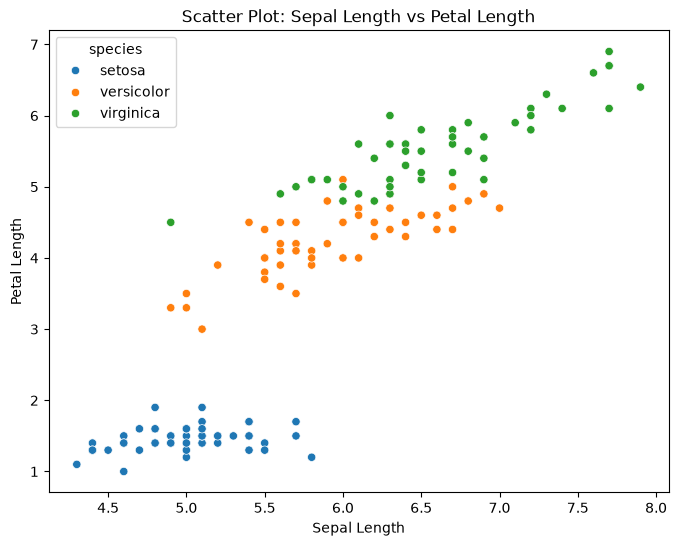

In [10]:
# Scatter Plot

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=iris,
    x="sepal_length",
    y="petal_length",
    hue="species"
)

plt.title("Scatter Plot: Sepal Length vs Petal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.show()

## 7. Conclusion

In this task, the Iris dataset was used to understand data preprocessing and outlier detection techniques.

The following techniques were implemented:

1. **Box and Whisker Plot** – Used to visualize the distribution of numerical data and identify possible outliers.

2. **Quartile Calculation** – Calculated Q1, Q2 (Median), and Q3 for numerical features.

3. **Tukey's Method** – Used IQR to calculate lower and upper bounds for detecting potential outliers.

4. **Z-Score** – Calculated how far each value is from the mean in terms of standard deviations.

5. **Standardization** – Transformed numerical features to a common scale with mean approximately 0 and standard deviation approximately 1.

6. **Scatter Plot** – Used to visualize the relationship between two numerical features.

This task provided practical understanding of data preprocessing, outlier detection, standardization, and data visualization techniques used in Data Analysis and Machine Learning.